[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap07/cap07_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:19%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 7 Classificação de Imagens e Reconhecimento de Padrões

🚧 **Em construção!**

No **Capítulo 6**, a transição da Parte I para a Parte II foi apresentada por meio de duas aplicações que já exigiam decisões automatizadas: o reconhecimento de marcas em folhas de resposta (OMR) e a detecção de defeitos em inspeção industrial. Em ambos os casos, no entanto, as decisões dependiam de regras geométricas e de limiares definidos manualmente, como determinar se um disco era suficientemente circular ou se uma região era escura o bastante.

Este capítulo formaliza o problema mais geral subjacente a essas aplicações: dado um conjunto de exemplos rotulados, como treinar um sistema para **classificar automaticamente** novas imagens ou regiões de interesse? Essa questão está no núcleo do **Reconhecimento de Padrões**, disciplina que fundamenta grande parte das tarefas modernas de Visão Computacional, desde a classificação de imagens até a detecção de objetos e a segmentação semântica, exploradas nos próximos capítulos.

Serão estudados os principais **descritores clássicos de imagem** (cor, textura e forma/gradiente) e o classificador **k-Vizinhos mais Próximos** (*k-Nearest Neighbors* — k-NN), escolhido por sua simplicidade conceitual e por evidenciar, de forma direta, a relação entre o espaço de características, as métricas de distância e as fronteiras de decisão — conceitos que permanecem centrais mesmo em classificadores baseados em redes neurais profundas, estudados no capítulo final desta parte.


## 7.1 Objetivos do Capítulo

Ao final deste capítulo, o estudante deverá ser capaz de:

* Compreender o ***pipeline* clássico de reconhecimento de padrões**: aquisição, pré-processamento, extração de descritores, classificação e avaliação;
* **Extrair e interpretar descritores clássicos** de cor, textura (*Local Binary Patterns* — LBP) e forma/gradiente (*Histogram of Oriented Gradients* — HOG);
* **Implementar e treinar um classificador k-NN** para tarefas de classificação de imagens;
* **Avaliar classificadores** por meio de métricas como acurácia, matriz de confusão, precisão e revocação;
* **Analisar o efeito do parâmetro k** e da dimensionalidade do espaço de características no desempenho do classificador;
* **Reconhecer as limitações dos descritores artesanais** (*hand-crafted features*) e compreender a motivação para a transição, nos próximos capítulos, para descritores aprendidos automaticamente.

## 7.2 Configuração do Ambiente

Os exemplos deste capítulo utilizam bibliotecas amplamente empregadas em
Processamento Digital de Imagens, Visão Computacional e Aprendizado de
Máquina. O bloco abaixo instala os pacotes necessários; em ambientes que já
os possuam, a execução pode ser ignorada.

In [1]:
# Instala apenas bibliotecas ausentes
import importlib
import subprocess
import sys

PACOTES = {
    "cv2": "opencv-python",
    "skimage": "scikit-image",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "tabulate": "tabulate",
    "kaleido": "kaleido",
}

for modulo, pacote in PACOTES.items():
    try:
        importlib.import_module(modulo)
    except ImportError:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pacote],
            check=True
        )

# ==========================================================
# Bibliotecas
# ==========================================================

# Computação científica
import numpy as np
import pandas as pd

# Visualização
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

# Visão computacional
import cv2
from skimage import data as skdata
from skimage.feature import hog, local_binary_pattern

# Aprendizado de máquina
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

Assim como no capítulo anterior, será utilizado o módulo didático
`morph.py`, responsável por padronizar a leitura, a exibição e o
processamento de imagens ao longo do livro.

In [2]:
import os
import urllib.request

if not os.path.exists("morph.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/morph.py",
        "morph.py",
    )

import morph
from morph import mm

print(f"✅ Ambiente pronto. morph {getattr(morph, '__version__', 'local_file')}")


✅ Ambiente pronto. morph 1.1.5


## 7.3 Um Problema Concreto: Classificação de Frutas

Antes de apresentar os fundamentos teóricos, considere o seguinte problema,
que será utilizado como exemplo ao longo deste capítulo para ilustrar os
principais conceitos de reconhecimento de padrões.

**O cenário:** Uma fazenda automatizada utiliza um sistema de Visão
Computacional para separar maçãs, bananas e laranjas em linhas de
embalagem.

**O desafio:** As frutas chegam à esteira em diferentes posições e
orientações, sob condições de iluminação que podem variar. Além disso,
folhas, sombras e pequenas oclusões podem dificultar sua identificação.
Como desenvolver um sistema capaz de classificá-las corretamente?

**Uma possível abordagem:**

1. Extrair descritores que representem características relevantes das
   frutas:
   - **Cor:** distribuição predominante das cores;
   - **Textura:** diferenças na superfície da casca;
   - **Forma:** características geométricas do contorno.

2. Treinar um classificador utilizando exemplos previamente rotulados.

3. Utilizar o modelo treinado para classificar automaticamente novas
   frutas.

A [Figura 7.1](#fig-07-frutas-motivacao) ilustra, de forma conceitual, como diferentes
frutas podem ser representadas em um espaço de características
tridimensional.

> ### 💡 Reflita antes de continuar
>
> Se cada fruta fosse representada apenas pelos valores de intensidade de
> seus pixels, seria possível distingui-las de forma confiável? Que tipos de
> informação poderiam ser extraídos da imagem para facilitar essa tarefa?

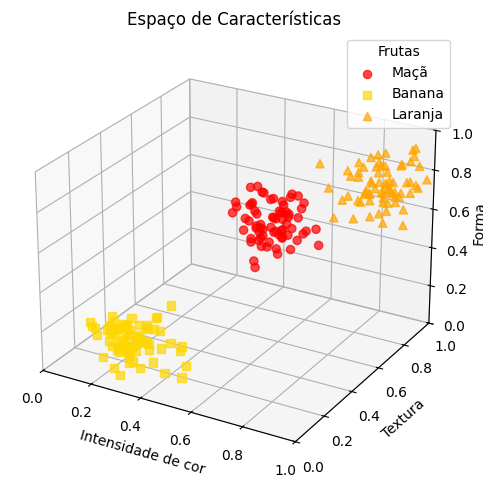

**Figura 7.1:** Exemplo motivacional: diferentes frutas formando agrupamentos distintos em um espaço de características.


In [3]:
np.random.seed(42)

centros = {
    "Maçã":    [0.8, 0.2, 0.9],
    "Banana":  [0.3, 0.1, 0.2],
    "Laranja": [0.9, 0.8, 0.8],
}

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")

for fruta, centro, cor, marcador in zip(
    centros,
    centros.values(),
    ["red", "gold", "orange"],
    ["o", "s", "^"],
):
    X = np.clip(np.random.normal(centro, 0.08, (70, 3)), 0, 1)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2],
               c=cor, marker=marcador, s=35,
               alpha=0.7, label=fruta)

ax.set(
    xlim=(0,1), ylim=(0,1), zlim=(0,1),
    xlabel="Intensidade de cor",
    ylabel="Textura",
    zlabel="Forma",
    title="Espaço de Características"
)
ax.view_init(elev=25, azim=-60)
ax.legend(title="Frutas")
ax.zaxis.labelpad = 0.01

plt.tight_layout()
plt.show()

## 7.4 🗺️ Panorama do Capítulo: O *Pipeline* Clássico de Classificação de Imagens

Antes de prosseguir, é útil apresentar uma visão integrada do que será
estudado. A [Figura 7.2](#fig-07-infografo) mostra o fluxo geral de um sistema
clássico de classificação de imagens, desde a imagem de entrada até a
etapa de atribuição do rótulo final. Nas próximas seções, cada uma das
etapas desse processo será estudada em detalhes.

<figure id="fig-07-infografo" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-07-infografo.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 7.2:</strong> Panorama do *pipeline* clássico de classificação de imagens: extração de descritores (LBP, HOG), formação do espaço de características e classificação via k-NN. Não se aplica a modelos de *deep learning* (CNNs, YOLO), que aprendem *features end-to-end* diretamente dos pixels. **Fonte:** elaborado com auxílio do Gemini Notebook ({GOOGLE}, 2025).</figcaption>
</figure>

> ### 📝 Escopo deste capítulo
>
> Neste capítulo, o foco recai exclusivamente sobre o classificador k-NN,
> por sua simplicidade didática e por ilustrar de forma intuitiva o
> conceito de espaço de características. Outros classificadores
> tradicionais amplamente utilizados em Reconhecimento de Padrões — como
> Árvores de Decisão, Regras de Classificação e Máquinas de Vetores de
> Suporte (SVM) — são discutidos em profundidade em
> Quilici-Gonzalez e Zampirolli (2014), especialmente em sua 2ª edição, atualmente
> em produção (QUILICI-GONZALEZ et al., 2026).

## 7.5 Fundamentos de Reconhecimento de Padrões

Um sistema de **reconhecimento de padrões** tem como objetivo atribuir uma
categoria (rótulo) a uma observação — uma imagem inteira, uma região de
interesse ou um sinal — com base em exemplos previamente rotulados. De
forma geral, esse processo é organizado nas seguintes etapas:

1. **Aquisição:** obtenção da imagem ou do sinal a ser classificado;
2. **Pré-processamento:** normalização, remoção de ruído, correção
   geométrica ou de iluminação — etapas já estudadas nos capítulos
   anteriores;
3. **Extração de descritores (*features*):** transformação da imagem em
   um **vetor de características** de dimensão fixa, que representa as
   propriedades relevantes para a tarefa de classificação;
4. **Classificação:** aplicação de um modelo que associa o vetor de
   características a uma classe;
5. **Avaliação:** análise do desempenho do modelo em um conjunto de dados
   independente daquele utilizado para o treinamento.

O conjunto de todos os vetores de características possíveis constitui o
**espaço de características** (*feature space*). Um bom descritor produz
representações que aproximam, nesse espaço, observações da mesma classe e
afastam observações de classes distintas. Essa propriedade favorece
métodos de classificação baseados em proximidade, como o **k-NN**, e
também beneficia diversos outros classificadores.

A [Figura 7.1](#fig-07-frutas-motivacao) ilustra esse conceito de forma esquemática:
cada fruta é representada por um ponto em um espaço de características de
três dimensões (cor, textura e forma). Embora esse espaço seja apenas uma
simplificação didática, ele mostra como amostras da mesma classe tendem a
formar agrupamentos, enquanto classes diferentes ocupam regiões distintas,
facilitando a tarefa de classificação.

## 7.6 Extração de Descritores Clássicos

Antes da popularização das redes neurais profundas, os descritores de
imagem eram, em sua maioria, projetados manualmente por especialistas
(*hand-crafted features*), com base em propriedades estatísticas ou
geométricas conhecidas. Três famílias clássicas são particularmente
relevantes:

* **Descritores de cor:** histogramas de intensidade ou de matiz,
  que capturam a distribuição dos valores de cor de uma região, já
  introduzidos no **Capítulo 3** por meio da função `mm.hist`;
* **Descritores de textura:** capturam padrões locais de repetição,
  rugosidade ou orientação, como o *Local Binary Patterns* (LBP),
  estudado a seguir;
* **Descritores de forma/gradiente:** descrevem a distribuição das
  bordas e das orientações do gradiente, como o *Histogram of Oriented
  Gradients* (HOG), amplamente empregado na detecção de pessoas e
  outros objetos.

Para entender por que descritores são tão poderosos, a [Figura 7.3](#fig-07-visualizacao-descritores)
mostra como diferentes técnicas "enxergam" a mesma imagem.

In [4]:
# Carregar imagem de exemplo
imagem = data.camera()

# Aplicar descritores
lbp_img = local_binary_pattern(
    imagem, 
    P=8, 
    R=1, 
    method="uniform"
    )

# Converter o LBP para RGB apenas para facilitar a visualização
lbp_norm = (lbp_img - lbp_img.min()) / (lbp_img.max() - lbp_img.min() + 1e-8)
lbp_rgb = (cm.nipy_spectral(lbp_norm)[..., :3] * 255).astype("uint8")

_, hog_img = hog(
    imagem,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
)

# Exibição padronizada
mm.show(
    [imagem, lbp_rgb, hog_img],
    titles=[
        "Imagem Original\n(como o humano vê)",
        "LBP: Textura\n(cada cor = um código LBP)",
        "HOG: Gradientes e Contornos\n(regiões claras = maior intensidade)",
    ],
    cols=3,
    figsize=(12, 4),
)

print("Observe como cada descritor destaca propriedades diferentes:")
print("• LBP: evidencia padrões locais de textura.")
print("• HOG: evidencia contornos e orientações das bordas.")
print("• Imagem original: contém apenas os valores de intensidade.")

NameError: name 'data' is not defined

**Figura 7.3:** Comparação visual de diferentes descritores aplicados à mesma imagem. Cada descritor revela aspectos distintos da cena.


### 7.6.1 *Local Binary Patterns* (LBP)

O LBP é um descritor de textura que codifica, para cada pixel central
$g_c$, a relação entre sua intensidade e a dos $P$ vizinhos dispostos em
uma vizinhança circular de raio $R$:

$$
\mathrm{LBP}_{P,R}(x_c, y_c) = \sum_{p=0}^{P-1} s(g_p - g_c)\, 2^p,
\qquad
s(z) =
\begin{cases}
1, & z \geq 0 \\
0, & z < 0
\end{cases}
$$

em que:

- $(x_c, y_c)$ são as coordenadas do pixel central;
- $g_c$ é a intensidade do pixel central;
- $g_p$ é a intensidade do $p$-ésimo pixel vizinho;
- $P$ é o número de vizinhos considerados;
- $R$ é o raio da vizinhança circular;
- $p$ é o índice do vizinho, com $p = 0, 1, \ldots, P-1$;
- $s(z)$ é a função limiar definida na equação, em que $z = g_p - g_c$;
  ela assume valor 1 quando $z \geq 0$ e 0 quando $z < 0$;
- $2^p$ corresponde ao peso binário associado ao $p$-ésimo vizinho.

O código LBP obtido descreve o padrão local de contraste ao redor do
pixel central. O histograma dos códigos LBP calculados em uma região
constitui um vetor de características compacto para representar sua
textura. Neste capítulo utiliza-se a variante *uniforme*, que reduz o
número de padrões possíveis ao agrupar padrões não uniformes,
produzindo descritores mais compactos e robustos.

> ### 💡 Função `local_binary_pattern`
>
> A implementação utilizada neste capítulo é fornecida pela biblioteca
> `scikit-image`:
>
> ```python
> local_binary_pattern(
>     imagem,
>     P=8,
>     R=1,
>     method="uniform"
> )
> ```
>
> onde:
>
> * `image`: imagem em escala de cinza;
> * `P`: número de vizinhos igualmente espaçados na vizinhança circular;
> * `R`: raio da vizinhança, em pixels;
> * `method`: estratégia de codificação. Neste capítulo utiliza-se o valor
>   `"uniform"`.
>
> A equação apresentada anteriormente descreve o **LBP original**. Na
> implementação adotada neste capítulo, a opção `method="uniform"`
> calcula inicialmente esse código e, em seguida, remapeia os padrões não
> uniformes para uma única categoria, reduzindo a dimensionalidade do
> descritor e tornando-o mais robusto a pequenas variações locais.

A [Figura 7.3](#fig-07-visualizacao-descritores) ilustra o processo de codificação dos
padrões locais de textura pelo descritor LBP.

O **Projeto Prático 2** (seção **Classificação de Texturas com Descritores LBP**) emprega o LBP na classificação de diferentes tipos de textura sintética.

### 7.6.2 *Histogram of Oriented Gradients* (HOG)

O HOG é um descritor que representa a forma de um objeto por meio da
distribuição das orientações do gradiente local. Assim como no operador
de Canny (**Capítulo 6**), calcula-se inicialmente o gradiente:

$$
|\nabla f(x,y)| =
\sqrt{\left(\frac{\partial f}{\partial x}\right)^2 +
      \left(\frac{\partial f}{\partial y}\right)^2},
\qquad
\theta(x,y) =
\operatorname{atan2}\!\left(
\frac{\partial f}{\partial y},
\frac{\partial f}{\partial x}
\right).
$$

em que:

- $f(x,y)$ é a intensidade da imagem no pixel $(x,y)$;
- $\frac{\partial f}{\partial x}$ e $\frac{\partial f}{\partial y}$ são,
  respectivamente, as derivadas parciais da imagem nas direções
  horizontal e vertical;
- $|\nabla f(x,y)|$ é a magnitude do vetor gradiente no pixel $(x,y)$,
  indicando a intensidade da variação local da imagem;
- $\theta(x,y)$ é a orientação do vetor gradiente no pixel $(x,y)$,
  calculada pela função $\operatorname{atan2}$, cujo resultado pertence ao
  intervalo $(-\pi,\pi]$.

Embora $\theta(x,y)$, como calculado pela função $\operatorname{atan2}$, pertença ao intervalo $(-\pi,\pi]$, a implementação padrão do HOG utiliza o **gradiente não sinalizado** (*unsigned*): orientações opostas (por exemplo, $0$ e $\pi$) são tratadas como equivalentes, e os ângulos são mapeados para o intervalo $[0,\pi)$ antes da construção do histograma. Essa escolha torna o descritor invariante à direção do contraste (por exemplo, uma borda clara-escura e uma borda escura-clara produzem a mesma orientação).

A imagem é então dividida em **células** (*cells*). Para cada célula,
constrói-se um histograma das orientações do gradiente, ponderado pela
magnitude correspondente. A concatenação dos histogramas de todas as
células forma o vetor de características HOG, que representa a
distribuição espacial das orientações do gradiente e captura informações
sobre a forma e os contornos do objeto.

> ### 💡 Função `hog`
>
> A extração do descritor HOG é realizada pela função:
>
> ```python
> hog(
>     image,
>     orientations=9,
>     pixels_per_cell=(8, 8),
>     cells_per_block=(2, 2),
>     visualize=True,
> )
> ```
>
> Os principais parâmetros são:
>
> * `image`: imagem de entrada;
> * `orientations`: número de divisões angulares do histograma de orientações em cada célula;
> * `pixels_per_cell`: tamanho, em pixels, de cada célula onde o histograma é calculado;
> * `cells_per_block`: número de células utilizadas na normalização do descritor;
> * `visualize`: quando `True`, retorna também uma imagem ilustrando os gradientes utilizados pelo HOG.
>
> A equação apresentada anteriormente descreve o cálculo da magnitude e da
> orientação do gradiente, que constituem a base do descritor HOG. Na
> implementação adotada neste capítulo, a função `hog()` utiliza essas
> informações para construir histogramas de orientações em cada célula da
> imagem e, em seguida, realiza a normalização em blocos (`cells_per_block`),
> reduzindo a sensibilidade do descritor a variações de iluminação e contraste.


A [Figura 7.3](#fig-07-visualizacao-descritores) ilustra a representação produzida pelo
descritor HOG a partir da imagem original.

O **Projeto Prático 1** (seção **Classificação de Dígitos Manuscritos com k-NN**)
compara o desempenho de descritores HOG com o uso direto das intensidades
dos pixels como vetor de características.

### 7.6.3 O Impacto da Escala e a Normalização de Características

O classificador $k$-NN toma suas decisões com base na distância entre os
vetores de características. Por isso, a escala de cada característica
influencia diretamente o resultado da classificação. Se uma variável
apresentar valores muito maiores do que as demais (por exemplo, uma
intensidade de cor variando de $0$ a $255$, enquanto um índice de
circularidade varia de $0$ a $1$), ela tende a dominar o cálculo da
distância, reduzindo a influência dos outros descritores.

Para evitar esse problema, aplica-se uma etapa de **normalização das
características**, geralmente por meio da padronização (*Z-score
standardization*). Nesse procedimento, cada característica passa a ter
média igual a zero e desvio-padrão igual a um, tornando comparáveis
grandezas originalmente medidas em escalas diferentes.

A padronização é realizada pela transformação

$$
z = \frac{x - \mu}{\sigma},
$$

em que:

- $x$ é o valor original da característica;
- $\mu$ é a média dessa característica calculada sobre o conjunto de treinamento;
- $\sigma$ é o desvio-padrão da característica;
- $z$ é o valor padronizado.

Após essa transformação, todas as características passam a possuir média
igual a zero e desvio-padrão igual a um, permitindo que contribuam de
forma equilibrada para o cálculo das distâncias.

> ### 💡 Classe `StandardScaler`
>
> A padronização utilizada neste capítulo é realizada pela classe
> `StandardScaler`, da biblioteca `scikit-learn`:
>
> ```python
> from sklearn.preprocessing import StandardScaler
>
> scaler = StandardScaler()
> X_norm = scaler.fit_transform(X)
> ```
>
> em que:
>
> * `StandardScaler()`: cria o objeto responsável pela padronização;
> * `fit_transform(X)`: calcula a média e o desvio-padrão de cada
>   característica do conjunto `X` e retorna a matriz padronizada.
>
> Na prática, o método `fit_transform()` executa duas etapas: primeiro
> (`fit`), estima a média ($\mu$) e o desvio-padrão ($\sigma$) de cada
> característica; em seguida (`transform`), aplica a transformação de padronização apresentada anteriormente a todos os valores da matriz de entrada.

A [Figura 7.4](#fig-07-normalizacao-features) mostra o efeito da normalização.
Visualmente, a distribuição dos pontos permanece a mesma; o que muda é a
escala dos eixos. Sem a normalização, a característica de maior
magnitude domina o cálculo das distâncias entre as amostras. Após a padronização, todas as características passam a contribuir de
forma equilibrada para o cálculo das distâncias utilizadas pelo
classificador $k$-NN.

In [ ]:
# Dados sintéticos com escalas muito diferentes
np.random.seed(42)
X_demo = np.random.randn(20, 2) * [100, 1]
y_demo = np.array([0] * 10 + [1] * 10)

print("Efeito da normalização:")
print("  Característica 1: escala ≈ 100")
print("  Característica 2: escala ≈ 1")
print("\nSem normalização, a primeira característica domina o cálculo das distâncias.")
print("Com normalização, ambas contribuem de forma equilibrada.")
print("\nA normalização é essencial quando as características possuem escalas diferentes.")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sem normalização
axes[0].scatter(
    X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1],
    c="blue", label="Classe 0"
)
axes[0].scatter(
    X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1],
    c="red", label="Classe 1"
)
axes[0].set_title("Sem Normalização\n(escalas diferentes)")
axes[0].set_xlabel("Característica 1 (escala 100)")
axes[0].set_ylabel("Característica 2 (escala 1)")
axes[0].legend()

# Com normalização
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_demo)

axes[1].scatter(
    X_norm[y_demo == 0, 0], X_norm[y_demo == 0, 1],
    c="blue", label="Classe 0"
)
axes[1].scatter(
    X_norm[y_demo == 1, 0], X_norm[y_demo == 1, 1],
    c="red", label="Classe 1"
)
axes[1].set_title("Com Normalização\n(características balanceadas)")
axes[1].set_xlabel("Característica 1")
axes[1].set_ylabel("Característica 2")
axes[1].legend()

plt.tight_layout()
plt.show()

**Figura 7.4:** Importância da normalização das características para o classificador k-NN.


## 7.7 📌 Mapa Conceitual

Até aqui, foram apresentados os descritores clássicos (LBP, HOG, pixels
brutos) e a forma como eles organizam as amostras em um espaço de
características. A [Figura 7.5](#fig-07-mapa-conceitual) sintetiza esse percurso e
situa essas etapas dentro do fluxo geral de um sistema clássico de
classificação de imagens, indicando também as etapas seguintes —
classificação (k-NN) e avaliação dos
resultados — que serão formalizadas nas próximas seções.

<figure id="fig-07-mapa-conceitual" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-07-mapa-conceitual.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 7.5:</strong> Mapa conceitual do processo de classificação de imagens utilizando descritores clássicos (LBP, HOG, pixels brutos) e classificador tradicional (k-NN). Não se aplica a modelos de *deep learning* (CNNs, YOLO), que aprendem *features end-to-end* diretamente dos pixels.</figcaption>
</figure>

## 7.8 Descritores na Prática

Após conhecer os principais descritores clássicos, é natural perguntar
como eles influenciam o desempenho de um classificador em situações
próximas às encontradas na prática.

Nesta seção, compara-se o uso de três representações distintas das
mesmas imagens: intensidades dos pixels, descritores LBP e descritores
HOG. Para tornar o experimento mais realista, adiciona-se ruído sintético
aos dados, em intensidades diferentes para cada descritor — uma forma
simplificada de simular o fato de que, na prática, diferentes
representações toleram de forma desigual as imperfeições da captura
(ruído do sensor, pequenas variações de posição, etc.).

A [Figura 7.6](#fig-07-matrizes-confusao) apresenta as matrizes de confusão obtidas
para cada descritor, permitindo identificar em quais classes ocorrem os
principais erros de classificação. 
A interpretação dessas matrizes foi introduzida no **Capítulo 1**, quando
foram apresentados os conceitos de **Verdadeiro Positivo (VP)**,
**Falso Positivo (FP)**, **Verdadeiro Negativo (VN)** e **Falso Negativo (FN)**.
Esses conceitos foram explorados nos **EPs 01_02** (métricas de classificação)
e **01_03** (*mean Average Precision* – mAP), disponíveis em:

- <https://fzampirolli.github.io/pdi-vc/eps/py.pt/EP01_02.html>
- <https://fzampirolli.github.io/pdi-vc/eps/py.pt/EP01_03.html>

Neste capítulo, as matrizes de confusão são empregadas para analisar
como diferentes descritores influenciam o desempenho do classificador.

Em seguida, a [Figura 7.7](#fig-07-comparacao-descritores-detalhada) resume a acurácia
global obtida por cada descritor.

Os resultados mostram que o desempenho do classificador depende
diretamente da representação escolhida para descrever as imagens.
Enquanto o uso direto das intensidades dos pixels é mais sensível às
degradações introduzidas, os descritores LBP e HOG preservam melhor as
informações relevantes para a classificação, resultando em maior
desempenho nesse cenário. É importante ressaltar que os níveis de ruído
aplicados a cada descritor foram escolhidos apenas para fins didáticos,
de modo a ilustrar o princípio geral de que descritores mais elaborados
*podem* ser mais robustos a degradações — o que não significa que essa
relação se verifique sempre, como o estudo de caso da próxima seção
demonstrará.

> ### 💡 Como o experimento é realizado
>
> Como o objetivo desta seção é comparar apenas o efeito dos descritores,
> gera-se um conjunto de dados sintético simples: três nuvens de pontos
> gaussianas, centradas nos mesmos valores de "cor, textura e forma" já
> utilizados na [Figura 7.1](#fig-07-frutas-motivacao) — o mesmo padrão empregado desde o
> início do capítulo para representar as três classes de frutas.
>
> ```python
> import numpy as np
> from sklearn.model_selection import train_test_split
> from sklearn.neighbors import KNeighborsClassifier
> from sklearn.metrics import accuracy_score, confusion_matrix
> ```
>
> ```python
> centros = {
>     "Maçã":    [0.8, 0.2, 0.9],
>     "Banana":  [0.3, 0.1, 0.2],
>     "Laranja": [0.9, 0.8, 0.8],
> }
>
> n_por_classe = 100
> X = np.vstack([
>     np.random.normal(centro, 0.12, (n_por_classe, 3))
>     for centro in centros.values()
> ])
> y = np.repeat(list(centros.keys()), n_por_classe)
> ```
>
> em que:
>
> * `centros`: dicionário com o ponto médio de cada classe no espaço de características (cor, textura, forma);
> * `n_por_classe`: número de amostras geradas por classe;
> * `np.random.normal(centro, 0.12, (n_por_classe, 3))`: gera `n_por_classe` amostras ao redor de cada centro, com desvio-padrão 0,12 em cada dimensão;
> * `np.repeat(list(centros.keys()), n_por_classe)`: gera o vetor de rótulos correspondente, na mesma ordem dos centros.
>
> Em seguida, utiliza-se o fluxo de treinamento e avaliação:
>
> * `train_test_split(X, y, test_size=0.3)`: divide os dados em treinamento (70%) e teste (30%);
> * `KNeighborsClassifier(n_neighbors=5)`: cria um classificador $k$-NN com $k=5$ vizinhos;
> * `fit(X_train, y_train)`: ajusta o modelo aos dados de treinamento;
> * `predict(X_test)`: classifica as amostras de teste;
> * `accuracy_score(y_test, y_pred)`: calcula a acurácia;
> * `confusion_matrix(y_test, y_pred)`: gera a matriz de confusão.
>
> Neste experimento, o conjunto de treinamento, o classificador e o método
> de avaliação permanecem exatamente os mesmos. A única diferença entre os
> experimentos é a representação utilizada para cada imagem (pixels
> brutos, LBP ou HOG), permitindo avaliar exclusivamente a influência do
> descritor sobre o desempenho do classificador.

In [ ]:
classes = ["Maçã", "Banana", "Laranja"]

np.random.seed(42)

# Mesmos centros de classe (cor, textura, forma) utilizados no
# exemplo anterior, agora reaproveitados para gerar os dados
# sintéticos de treino e teste deste experimento.
centros = {
    "Maçã":    [0.8, 0.2, 0.9],
    "Banana":  [0.3, 0.1, 0.2],
    "Laranja": [0.9, 0.8, 0.8],
}

n_por_classe = 100
X = np.vstack([
    np.random.normal(centro, 0.12, (n_por_classe, 3))
    for centro in centros.values()
])
y = np.repeat(list(centros.keys()), n_por_classe)

# Simular descritores com diferentes níveis de sensibilidade ao ruído.
# Quanto maior o ruído adicionado, pior tende a ser a representação.
descritores = {
    "Pixels Brutos": X + 0.5 * np.random.randn(*X.shape),
    "LBP":           X + 0.3 * np.random.randn(*X.shape),
    "HOG":           X + 0.2 * np.random.randn(*X.shape),
}

# Criar uma única figura com 3 subplots lado a lado para as matrizes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
resultados = {}

for idx, (nome, Xd) in enumerate(descritores.items()):
    X_train, X_test, y_train, y_test = train_test_split(Xd, y, test_size=0.3, random_state=42)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc
    
    # Matriz de confusão no subplot correspondente

    cm = confusion_matrix(y_test, y_pred, labels=classes)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=classes,
        yticklabels=classes,
        ax=axes[idx],
    )

    axes[idx].set_title(
        f"{nome}\nAcurácia: {acc:.3f}",
        fontsize=11,
        fontweight="bold"
    )
    axes[idx].set_xlabel("Classe Predita")
    axes[idx].set_ylabel("Classe Real")


plt.tight_layout()
plt.show()


**Figura 7.6:** Matrizes de confusão obtidas pelo classificador k-NN utilizando três descritores diferentes. As linhas representam a classe real (Maçã, Banana e Laranja) e as colunas a classe predita. Quanto maior a concentração de valores na diagonal principal, melhor o desempenho do descritor.


In [ ]:
# Comparação visual em uma figura isolada
plt.figure(figsize=(6, 3.5))
nomes = list(resultados.keys())
acuracia = list(resultados.values())
colors = ['#6366f1', '#f97316', '#22c55e']

bars = plt.bar(nomes, acuracia, color=colors, width=0.5)
plt.ylabel('Acurácia Global')
plt.title('Desempenho Geral dos Descritores sob Ruído Realista', fontsize=12, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adicionar os valores acima das barras usando round padrão para exibição
for bar, val in zip(bars, acuracia):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("Análise dos resultados:")
print("- Pixels Brutos: Sensíveis a variações locais de iluminação e ruído.")
print("- LBP: Boa tolerância para variações monotônicas de iluminação global.")
print("- HOG: Excelente para contornos e formas estáveis sob pequenas flutuações geométricas.")

**Figura 7.7:** Comparação detalhada de acurácia global em cenário realista. Observe como os descritores extraídos estruturalmente (LBP e HOG) superam o uso de intensidades puras de pixels brutos.


## 7.9 Um Problema Concreto: Simulando Descritores de Frutas

Retomando o problema de classificação de frutas apresentado no início do capítulo, cada imagem pode ser representada por um vetor de características (*feature vector*) obtido a partir da extração de descritores de cor, textura e forma. A [Tabela 7.1](#tbl-descritores-frutas) apresenta alguns descritores frequentemente utilizados em aplicações de Visão Computacional, incluindo técnicas introduzidas no Capítulo 3 e neste capítulo.

<a id="tbl-descritores-frutas"></a>

**Tabela 7.1:** Conjunto de descritores cromáticos, texturais e geométricos utilizados para representar imagens de frutas.

| Característica       | Descrição                                                |
|----------------------|----------------------------------------------------------|
| R, G, B              | intensidade média dos canais vermelho, verde e azul      |
| NC                   | intensidade média em níveis de cinza (*grayscale*)       |
| LBP                  | descritor de textura (*Local Binary Pattern*)            |
| HOG                  | descritor de forma (*Histogram of Oriented Gradients*)   |
| Área                 | número de pixels do objeto                               |
| Perímetro            | comprimento do contorno                                  |
| Circularidade        | medida de quão circular é o objeto                       |
| Razão largura/altura | proporção entre largura e altura da região               |


Nesse exemplo, cada imagem é representada pelo vetor

$$
X=(R,G,B,NC,\text{LBP},\text{HOG},\text{Área},\text{Perímetro},\text{Circularidade},\text{Razão}).
$$

> ### 📝 Simplificação adotada nesta tabela
>
> Na prática, LBP e HOG não são valores escalares, mas histogramas com dezenas ou centenas de componentes. Nesta seção, cada um deles é representado por um único valor apenas para simplificar a apresentação. Em aplicações reais, essas posições seriam substituídas pelas componentes completas dos respectivos histogramas.

Em aplicações reais, nem todos os descritores contribuem igualmente para distinguir as classes. Alguns fornecem informações mais relevantes, enquanto outros podem ser redundantes ou pouco discriminativos.

Para reproduzir esse cenário de forma controlada, será utilizado o `make_classification()`, da biblioteca `scikit-learn`. A função gera um conjunto de dados sintético cujas características podem ser interpretadas como descritores de imagens, permitindo definir quantas delas serão informativas para a classificação.

Neste exemplo, são geradas dez características sintéticas, das quais apenas sete (`n_informative=7`) participam da separação entre as três classes. As demais simulam atributos pouco informativos ou redundantes. A [Figura 7.8](#fig-07-make-classification-ilustracao) apresenta uma representação conceitual desse processo.

In [ ]:
# Configuração para reprodução
np.random.seed(42)

# Geração de dados sintéticos com características controladas
X, y = make_classification(
    n_samples=300,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_repeated=1,        # Uma característica é cópia de outra
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42,
)

# Criar figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Visualização das classes em 2D (usando duas características informativas)
# Identificar quais características são mais informativas
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importancias = rf.feature_importances_
caracteristicas_informativas = np.argsort(importancias)[-2:]  # Duas mais importantes

cores = {0: "#e74c3c", 1: "#f1c40f", 2: "#e67e22"}  # Maçã, Banana, Laranja
rotulos = {0: "Maçã", 1: "Banana", 2: "Laranja"}

for classe in range(3):
    idx = y == classe
    ax1.scatter(X[idx, caracteristicas_informativas[0]], 
               X[idx, caracteristicas_informativas[1]],
               c=cores[classe], label=rotulos[classe], 
               alpha=0.6, s=50, edgecolors="white", linewidth=0.5)

ax1.set_xlabel(f"Característica {caracteristicas_informativas[0]+1} (informativa)", fontsize=11)
ax1.set_ylabel(f"Característica {caracteristicas_informativas[1]+1} (informativa)", fontsize=11)
ax1.set_title("Classes no Espaço de Características\n(2 características informativas)", 
             fontsize=12, fontweight="bold")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)

# Subplot 2: Importância das características
bars = ax2.bar(range(1, 11), importancias, color="#4a90d9", alpha=0.7)
ax2.set_xlabel("Índice da Característica", fontsize=11)
ax2.set_ylabel("Importância", fontsize=11)
ax2.set_title("Importância de cada Característica\npara a Classificação", 
             fontsize=12, fontweight="bold")
ax2.set_xticks(range(1, 11))
ax2.grid(axis="y", alpha=0.3)

# Colorir barras para destacar características
cores_barras = ["#e74c3c" if i < 7 else "#95a5a6" for i in range(10)]
for bar, cor in zip(bars, cores_barras):
    bar.set_color(cor)

# Adicionar legenda
from matplotlib.patches import Patch
legenda_elements = [
    Patch(facecolor="#e74c3c", label="Características Informativas (7)"),
    Patch(facecolor="#95a5a6", label="Características Redundantes (3)")
]
ax2.legend(handles=legenda_elements, loc="upper right")

# Anotar o número de características informativas
ax2.axhline(y=0.15, color="red", linestyle="--", alpha=0.3)
ax2.text(0.5, 0.17, "Limiar de importância", fontsize=9, color="red", alpha=0.7)

plt.tight_layout()
plt.show()

print("\n🔍 Análise dos dados gerados:")
print(f"  • Total de amostras: {X.shape[0]}")
print(f"  • Número de características: {X.shape[1]}")
print(f"  • Características informativas: 7 (colunas 1 a 7 do gráfico)")
print(f"  • Características redundantes/repetidas: 3 (colunas 8 a 10 do gráfico)")
print(f"  • Distribuição das classes: {np.bincount(y)}")

**Figura 7.8:** Ilustração do processo de geração de dados sintéticos com *make_classification*. À esquerda, visualização das três classes em um espaço bidimensional formado por duas características informativas. À direita, importância relativa de cada característica para a classificação, evidenciando que apenas 7 das 10 características são efetivamente discriminativas.


## 7.10 Classificador k-NN: Como Funciona por Dentro

O **k-*Nearest Neighbors* (k-NN)** é um dos algoritmos de classificação mais simples e intuitivos da Aprendizagem de Máquina. Diferentemente de muitos classificadores, ele não constrói explicitamente um modelo durante a etapa de treinamento. Em vez disso, armazena as amostras rotuladas e, quando uma nova amostra precisa ser classificada, procura aquelas que mais se assemelham a ela.

O princípio do algoritmo baseia-se na hipótese de que amostras com características semelhantes tendem a pertencer à mesma classe. Para quantificar essa proximidade, o k-NN utiliza uma medida de distância entre os vetores de características.

Como exemplo, considere a [Tabela 7.2](#tbl-knn-frutas), que apresenta uma versão simplificada do problema de classificação de frutas utilizando apenas duas características: intensidade de cor e circularidade, ambas normalizadas no intervalo de 0 a 1.

<a id="tbl-knn-frutas"></a>

**Tabela 7.2:** Exemplo simplificado de classificação de frutas utilizando duas características normalizadas.

| Amostra         | Cor | Circularidade | Classe |
|-----------------|----:|--------------:|--------|
| Fruta 1         | 0,82 | 0,88 | Maçã |
| Fruta 2         | 0,30 | 0,20 | Banana |
| Fruta 3         | 0,88 | 0,85 | Maçã |
| Fruta ? (teste) | 0,80 | 0,90 | ? |


Observando apenas essas duas características, percebe-se que a fruta de teste está muito mais próxima das amostras rotuladas como **Maçã** do que da amostra rotulada como **Banana**. Na seção seguinte, essa noção intuitiva de proximidade será formalizada por meio de uma métrica de distância, utilizada pelo algoritmo para identificar os vizinhos mais próximos e decidir a classe da nova amostra.

### 7.10.1 Métrica de Distância

A proximidade entre duas amostras é normalmente quantificada pela
**distância euclidiana**, definida por

$$
d(x,x_i)=\|x-x_i\|_2=
\sqrt{\sum_{j=1}^{n}(x_j-x_{i,j})^2},
$$

em que:

-   $x$ é a amostra de teste;
-   $x_i$ é uma amostra do conjunto de treinamento;
-   $n$ é o número de características;
-   $x_j$ e $x_{i,j}$ representam a $j$-ésima característica.

Na implementação deste capítulo, $x$ corresponde a uma linha de `X_test`
e $x_i$ a uma linha de `X_train`. O método `predict()` calcula
automaticamente a distância entre $x$ e todas as amostras de
treinamento.

No exemplo da [Tabela 7.2](#tbl-knn-frutas):

$$
d(\text{teste}, \text{Fruta 1}) \approx 0{,}028,\qquad
d(\text{teste}, \text{Fruta 2}) \approx 0{,}860,\qquad
d(\text{teste}, \text{Fruta 3}) \approx 0{,}094.
$$

Como as menores distâncias correspondem às Frutas 1 e 3, essas amostras
serão utilizadas na etapa de decisão.

### 7.10.2 Regra de Decisão

Após ordenar as distâncias, o algoritmo seleciona os $k$ vizinhos mais
próximos. Seja $N_k(x)$ esse conjunto. A classe predita é dada por

$$
\hat y=\operatorname{moda}\{\,y_i:x_i\in N_k(x)\,\},
$$

em que $y_i$ é o rótulo da amostra $x_i$ e $\hat y$ é a classe atribuída
à amostra de teste.

No exemplo, para $k=3$, os vizinhos são Fruta 1 (Maçã), Fruta 3 (Maçã) e
Fruta 2 (Banana). Como **Maçã** recebe dois votos, essa é a classe
predita.

::: callout-tip
### Classe `KNeighborsClassifier`

Neste capítulo, o algoritmo é implementado com a classe
`KNeighborsClassifier`, da biblioteca `scikit-learn`:

``` python
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
```

em que:

-   `KNeighborsClassifier(n_neighbors=3)`: define o valor de $k$;
-   `fit(X_train, y_train)`: armazena as amostras de treinamento
    (`X_train`) e seus rótulos (`y_train`);
-   `predict(X_test)`: retorna as classes preditas para as amostras de
    `X_test`.

Internamente, `predict()` executa as etapas descritas anteriormente:
calcula as distâncias, identifica os $k$ vizinhos mais próximos e
determina a classe por votação majoritária.
:::

A [Figura 7.9](#fig-07-knn-passo-passo) ilustra esse procedimento em um conjunto
bidimensional. A figura destaca os vizinhos utilizados na classificação,
enquanto o console apresenta as etapas do algoritmo: cálculo das
distâncias, ordenação, seleção dos vizinhos, votação e predição da
classe.

In [ ]:
def knn_passo_a_passo(X, y, x, k=3):
    """Executa as cinco etapas do algoritmo k-NN.
    Parâmetros: X (treino), y (rótulos), x (teste) e k (número de vizinhos).
    """
    # 1. Distâncias
    dist = [(np.linalg.norm(x-xi), yi, i) for i, (xi, yi) in enumerate(zip(X, y))]
    print(f"1. Distâncias calculadas: {len(dist)}")

    # 2. Ordenação
    dist.sort(key=lambda t: t[0])
    print("2. Distâncias ordenadas")

    # 3. Seleção
    vizinhos = dist[:k]
    print(f"3. {k} vizinhos mais próximos:")
    for d, c, _ in vizinhos:
        print(f"   {d:.4f} → {c}")

    # 4. Votação
    votos = {}
    for _, c, _ in vizinhos:
        votos[c] = votos.get(c, 0) + 1
    print("4. Votos:", votos)

    # 5. Decisão
    classe = max(votos, key=votos.get)
    print("5. Classe predita:", classe)

    return classe, vizinhos


# Dados de exemplo
np.random.seed(4)
X = np.r_[np.random.randn(15,2)+[2,2],
          np.random.randn(15,2)+[-2,-2]]
y = np.array(["Classe A"]*15 + ["Classe B"]*15)
x = np.array([0.5,0.5])

classe, vizinhos = knn_passo_a_passo(X, y, x)

# Visualização
plt.figure(figsize=(5,5))

for c, rotulo in [("Classe A","Classe A"), ("Classe B","Classe B")]:
    P = X[y==c]
    plt.scatter(P[:,0], P[:,1], s=80, label=rotulo)

plt.scatter(*x, marker="*", s=220, edgecolors="black", label="Teste")

for _, _, i in vizinhos:
    plt.scatter(*X[i], s=220, facecolors="none", edgecolors="black", linewidths=2)
    plt.plot([x[0], X[i,0]], [x[1], X[i,1]], "--", lw=1)

plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title(f"k-NN ($k=3$): classe predita = {classe}")
plt.legend()
plt.grid(alpha=.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

**Figura 7.9:** Classificação de uma nova amostra pelo algoritmo k-NN. O ponto de teste (estrela) é classificado a partir dos três vizinhos mais próximos, destacados por círculos.


### 7.10.3 O Papel do Parâmetro $k$

O parâmetro $k$ determina quantos vizinhos participam da decisão de classificação.

- **Valores pequenos de $k$** (por exemplo, $k=1$) tornam o classificador mais sensível a ruídos e variações locais, produzindo fronteiras de decisão mais irregulares e favorecendo o *overfitting*.
- **Valores maiores de $k$** produzem fronteiras de decisão mais suaves, porém podem reduzir a sensibilidade a estruturas locais, favorecendo o *underfitting*.

Em problemas com duas classes, é comum utilizar valores ímpares de $k$ para reduzir a ocorrência de empates.

Outro aspecto importante é a **maldição da dimensionalidade** (*curse of dimensionality*). À medida que o número de características aumenta, as distâncias entre as amostras tendem a se tornar mais semelhantes, dificultando a identificação de vizinhos realmente representativos.

::: callout-note
### Resumo

O algoritmo k-NN pode ser resumido em três etapas:

1. extrair o vetor de características da nova amostra;
2. identificar os $k$ vizinhos mais próximos;
3. classificar a amostra pela classe mais frequente entre esses vizinhos.

O simulador da [Figura 7.10](#fig-07-sim-knn) permite explorar visualmente o efeito do parâmetro $k$ sobre a fronteira de decisão.
:::

In [ ]:
from IPython.display import HTML
HTML("""
<div id="knn7_Root">
<style>
  #knn7_Root * { box-sizing: border-box; }
  #knn7_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #374151; }
  #knn7_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #fff; cursor: crosshair; }
  #knn7_Root button { font-size: 11px; padding: 6px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; transition: background 0.15s; }
  #knn7_Root button:hover { background: #f3f4f6; }
  #knn7_Root button.knn7_active { background: #4f46e5; color: #fff; border-color: #4f46e5; }
  #knn7_Root input[type=range] { width: 100%; accent-color: #6366f1; }
  .knn7_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .knn7_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .knn7_stat { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .knn7_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 2px; }
  .knn7_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #4f46e5; }
  .knn7_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .knn7_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; }
  .knn7_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(0,0,0,0.2); }
</style>

<div class="knn7_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">Simulador: Fronteira de Decisão do k-NN</span>
  <span class="knn7_pill">Clique no canvas para adicionar pontos</span>
</div>

<div class="knn7_panel">
  <div class="knn7_row" style="margin-bottom:8px;">
    <div class="knn7_stat"><div class="knn7_stat_label">k</div><div id="knn7_kVal" class="knn7_stat_value">3</div></div>
    <div class="knn7_stat"><div class="knn7_stat_label">Pontos Azuis</div><div id="knn7_nAzul" class="knn7_stat_value">0</div></div>
    <div class="knn7_stat"><div class="knn7_stat_label">Pontos Vermelhos</div><div id="knn7_nVerm" class="knn7_stat_value">0</div></div>
    <button id="knn7_btnAzul">Adicionar Azul</button>
    <button id="knn7_btnVerm">Adicionar Vermelho</button>
    <button id="knn7_btnLimpar">Limpar</button>
    <button id="knn7_btnReset">Resetar</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#374151;">Valor de k: <span id="knn7_slVal">3</span></label>
  <input type="range" id="knn7_slider" min="1" max="15" step="1" value="3">
</div>

<canvas id="knn7_canvas" width="640" height="360"></canvas>

<div class="knn7_panel" style="margin-top:10px;">
  <div class="knn7_row" style="justify-content:space-between;">
    <div class="knn7_legend"><span class="knn7_dot" style="background:#3b82f6;"></span> Classe Azul</div>
    <div class="knn7_legend"><span class="knn7_dot" style="background:#ef4444;"></span> Classe Vermelha</div>
    <div style="font-size:11px;color:#6b7280;">A região colorida de fundo mostra a classe que o k-NN atribuiria a cada ponto do plano.</div>
  </div>
</div>
</div>

<script>
(function(){
  const knn7_canvas = document.getElementById("knn7_canvas");
  const knn7_ctx = knn7_canvas.getContext("2d");
  const knn7_W = knn7_canvas.width, knn7_H = knn7_canvas.height;
  const knn7_CELL = 10;

  let knn7_currentLabel = 0; // 0 = azul, 1 = vermelho
  let knn7_k = 3;
  let knn7_points = [];

  function knn7_defaultPoints(){
    return [
      {x:120,y:260,l:0},{x:150,y:230,l:0},{x:100,y:200,l:0},{x:160,y:290,l:0},
      {x:90,y:250,l:0},{x:140,y:190,l:0},{x:175,y:250,l:0},{x:110,y:150,l:0},
      {x:200,y:230,l:0},{x:130,y:310,l:0},
      {x:480,y:100,l:1},{x:450,y:130,l:1},{x:500,y:160,l:1},{x:440,y:80,l:1},
      {x:510,y:110,l:1},{x:470,y:60,l:1},{x:430,y:150,l:1},{x:520,y:190,l:1},
      {x:490,y:220,l:1},{x:460,y:190,l:1},
      {x:300,y:170,l:0},{x:320,y:190,l:1},{x:280,y:200,l:1},{x:310,y:150,l:0}
    ];
  }

  function knn7_classify(x, y, k, pontos){
    if (pontos.length === 0) return null;
    const dists = pontos.map(p => ({
      d: (p.x-x)*(p.x-x) + (p.y-y)*(p.y-y),
      l: p.l
    }));
    dists.sort((a,b) => a.d - b.d);
    const vizinhos = dists.slice(0, Math.min(k, dists.length));
    let votos = [0, 0];
    vizinhos.forEach(v => votos[v.l]++);
    return votos[1] > votos[0] ? 1 : 0;
  }

  function knn7_render(){
    knn7_ctx.clearRect(0, 0, knn7_W, knn7_H);

    // Região de decisão (grade de baixa resolução)
    for (let gy = 0; gy < knn7_H; gy += knn7_CELL){
      for (let gx = 0; gx < knn7_W; gx += knn7_CELL){
        const cx = gx + knn7_CELL/2, cy = gy + knn7_CELL/2;
        const classe = knn7_points.length > 0 ? knn7_classify(cx, cy, knn7_k, knn7_points) : null;
        if (classe === 0) knn7_ctx.fillStyle = "rgba(59,130,246,0.15)";
        else if (classe === 1) knn7_ctx.fillStyle = "rgba(239,68,68,0.15)";
        else knn7_ctx.fillStyle = "#ffffff";
        knn7_ctx.fillRect(gx, gy, knn7_CELL, knn7_CELL);
      }
    }

    // Pontos de treinamento
    knn7_points.forEach(p => {
      knn7_ctx.beginPath();
      knn7_ctx.arc(p.x, p.y, 7, 0, 2*Math.PI);
      knn7_ctx.fillStyle = p.l === 0 ? "#2563eb" : "#dc2626";
      knn7_ctx.fill();
      knn7_ctx.lineWidth = 1.5;
      knn7_ctx.strokeStyle = "#ffffff";
      knn7_ctx.stroke();
    });

    document.getElementById("knn7_nAzul").textContent = knn7_points.filter(p => p.l === 0).length;
    document.getElementById("knn7_nVerm").textContent = knn7_points.filter(p => p.l === 1).length;
    document.getElementById("knn7_kVal").textContent = knn7_k;
  }

  knn7_canvas.addEventListener("click", function(ev){
    const rect = knn7_canvas.getBoundingClientRect();
    const scaleX = knn7_canvas.width / rect.width;
    const scaleY = knn7_canvas.height / rect.height;
    const x = (ev.clientX - rect.left) * scaleX;
    const y = (ev.clientY - rect.top) * scaleY;
    knn7_points.push({x:x, y:y, l:knn7_currentLabel});
    knn7_render();
  });

  document.getElementById("knn7_slider").addEventListener("input", function(ev){
    knn7_k = parseInt(ev.target.value, 10);
    document.getElementById("knn7_slVal").textContent = knn7_k;
    knn7_render();
  });

  const knn7_btnAzul = document.getElementById("knn7_btnAzul");
  const knn7_btnVerm = document.getElementById("knn7_btnVerm");

  function knn7_setLabel(l){
    knn7_currentLabel = l;
    knn7_btnAzul.classList.toggle("knn7_active", l === 0);
    knn7_btnVerm.classList.toggle("knn7_active", l === 1);
  }

  knn7_btnAzul.addEventListener("click", function(){ knn7_setLabel(0); });
  knn7_btnVerm.addEventListener("click", function(){ knn7_setLabel(1); });

  document.getElementById("knn7_btnLimpar").addEventListener("click", function(){
    knn7_points = [];
    knn7_render();
  });

  document.getElementById("knn7_btnReset").addEventListener("click", function(){
    knn7_points = knn7_defaultPoints();
    knn7_render();
  });

  knn7_setLabel(0);
  knn7_points = knn7_defaultPoints();
  knn7_render();
})();
</script>
""")

**Figura 7.10:** Simulador interativo da fronteira de decisão do k-NN: adicione pontos de treinamento e ajuste o valor de k para observar o efeito sobre a região de decisão.


## 7.11 Projeto Prático 1: Classificação de Dígitos Manuscritos com k-NN

As seções anteriores apresentaram o algoritmo k-NN por meio de um exemplo simplificado de classificação de frutas, utilizando apenas duas características. A seguir, o mesmo algoritmo é aplicado a um conjunto de dados de imagens, no qual cada amostra é representada por um vetor de maior dimensão.

Como estudo de caso, utiliza-se a base pública `load_digits`, disponibilizada pela biblioteca `scikit-learn`. Esse conjunto de dados contém 1797 imagens de dígitos manuscritos das classes de 0 a 9, cada uma com resolução de $8 \times 8$ pixels em níveis de cinza. Cada imagem é representada por um vetor com 64 características, correspondentes às intensidades dos pixels, e cada vetor possui um rótulo indicando o dígito correspondente.

A base `load_digits` é disponibilizada pela biblioteca `scikit-learn` e é utilizada neste capítulo para ilustrar a aplicação do algoritmo k-NN. Além de estar disponível diretamente no `scikit-learn`, ela dispensa etapas adicionais de obtenção e preparação dos dados, permitindo concentrar a atenção na implementação e na avaliação do classificador.

A [Figura 7.11](#fig-07-digits-amostra) apresenta uma amostra das imagens da base de dados.

In [ ]:
digits = load_digits()
print(f"Total de amostras: {digits.data.shape[0]}, dimensão do vetor: {digits.data.shape[1]}")
print(f"Classes: {[int(i) for i in sorted(set(digits.target))]}")

n_amostras = 16
imgs = list(digits.images[:n_amostras])
imgs_titles = [str(label) for label in digits.target[:n_amostras]]
mm.show(imgs, titles=imgs_titles, cols=8, figsize=(12, 4))


**Figura 7.11:** Amostra de dígitos manuscritos da base *load_digits*, utilizada como estudo de caso de classificação.


### 7.11.1 Classificação com Vetores de Intensidade

Neste primeiro experimento, cada imagem de dimensão $8 \times 8$ é representada diretamente pelas intensidades de seus 64 pixels, sem a extração de descritores adicionais. Assim, cada amostra corresponde a um vetor de 64 características, utilizado como entrada do classificador k-NN.

Em seguida, o conjunto de dados é dividido em subconjuntos de treinamento e teste, preservando a proporção das dez classes por meio do parâmetro `stratify=y`. O classificador é treinado com $k=3$ e avaliado sobre o conjunto de teste utilizando a acurácia e a matriz de confusão apresentada na [Figura 7.12](#fig-07-knn-pixels).

In [ ]:
X, y = digits.data, digits.target

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n_neighbors = 3
knn_pixels = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_pixels.fit(X_treino, y_treino)
pred_pixels = knn_pixels.predict(X_teste)

acc_pixels = accuracy_score(y_teste, pred_pixels)
print(f"Acurácia (vetores de intensidade, k={n_neighbors}): {acc_pixels:.4f}")

cm = confusion_matrix(y_teste, pred_pixels)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=9
        )

plt.title("Matriz de Confusão — Pixels Brutos")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()


**Figura 7.12:** Matriz de confusão do classificador k-NN treinado com vetores de intensidade brutos (pixels).


### 7.11.2 Classificação com Descritores HOG

No experimento anterior, cada imagem foi representada diretamente pelas intensidades de seus pixels. Nesta seção, essa representação é substituída por descritores HOG (*Histogram of Oriented Gradients*), que codificam informações sobre a distribuição das orientações dos gradientes da imagem.

Mantêm-se o mesmo particionamento dos dados, o mesmo classificador k-NN e o mesmo protocolo de avaliação, alterando apenas a representação das imagens. A [Figura 7.13](#fig-07-comparativo-descritores) compara os resultados obtidos com vetores de intensidade e com descritores HOG.

In [ ]:
descritores_hog = np.array([
    hog(img, orientations=8, pixels_per_cell=(4, 4), cells_per_block=(1, 1))
    for img in digits.images
])
print(f"Dimensão do vetor HOG: {descritores_hog.shape[1]}")

Xh_treino, Xh_teste, yh_treino, yh_teste = train_test_split(
    descritores_hog, y, test_size=0.3, random_state=42, stratify=y
)

n_neighbors = 3
knn_hog = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_hog.fit(Xh_treino, yh_treino)
pred_hog = knn_hog.predict(Xh_teste)
acc_hog = accuracy_score(yh_teste, pred_hog)
print(f"Acurácia (descritor HOG, k={n_neighbors}): {acc_hog:.4f}")

plt.figure(figsize=(4, 3))
plt.bar(["Pixels brutos", "HOG"], [acc_pixels, acc_hog], color=["#6366f1", "#f97316"])
plt.ylim(0, 1.1)  # Aumenta o limite superior para dar espaço
plt.ylabel("Acurácia")
plt.title("Comparação de Descritores")
for i, v in enumerate([acc_pixels, acc_hog]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")  # Aumenta o deslocamento vertical
plt.tight_layout()

**Figura 7.13:** Comparação de acurácia entre descritores de pixels brutos e HOG para o classificador k-NN (k=3) na base de dígitos.


> ### 📝 Por que isso acontece?
>
> Na [Figura 7.13](#fig-07-comparativo-descritores), o classificador treinado com vetores de **intensidade dos pixels** alcança maior acurácia ($0.987$) do que aquele baseado em descritores **HOG** ($0.759$). Esse resultado está relacionado às características da base `load_digits`.
>
> As imagens possuem resolução de apenas $8\times8$ pixels, encontram-se aproximadamente centralizadas e apresentam pouca variação de iluminação, escala e orientação. Nesse cenário, as intensidades dos pixels preservam praticamente toda a informação necessária para distinguir as classes. Em contraste, o HOG resume a imagem em histogramas de orientações dos gradientes, reduzindo parte do detalhamento espacial disponível nos pixels originais.
>
> Essa redução de informação pode dificultar a separação de dígitos visualmente semelhantes, como 3 e 8 ou 4 e 9, especialmente quando a resolução da imagem é baixa.
>
> Em problemas com imagens de maior resolução ou sujeitas a variações de iluminação, posição, escala ou pequenas deformações, descritores como o HOG tendem a representar melhor a estrutura local da imagem do que os valores individuais dos pixels. Assim, este experimento ilustra um princípio importante da Aprendizagem de Máquina: **a representação dos dados deve ser escolhida de acordo com as características do problema e não pela complexidade do descritor.**

## 7.12 Avaliação de Classificadores

Nas seções anteriores, a qualidade do classificador foi analisada por
meio da acurácia e da matriz de confusão. Nesta seção, essas ferramentas
são complementadas por métricas utilizadas na avaliação de modelos e por
um procedimento para selecionar o valor do parâmetro $k$.

A acurácia corresponde à proporção de amostras classificadas
corretamente. Embora seja uma medida simples e amplamente utilizada, ela
pode ser insuficiente quando as classes apresentam distribuições muito
desbalanceadas.

A partir da matriz de confusão — introduzida no **Capítulo 1** e
utilizada ao longo deste capítulo — podem ser calculadas métricas por
classe, como precisão e revocação:

$$
\text{Precisão}=\frac{VP}{VP+FP},
\qquad
\text{Revocação}=\frac{VP}{VP+FN},
$$

em que $VP$, $FP$ e $FN$ representam, respectivamente, o número de
verdadeiros positivos, falsos positivos e falsos negativos da classe
analisada. A precisão quantifica a proporção de predições positivas
corretas, enquanto a revocação mede a capacidade do classificador de
identificar os exemplos pertencentes à classe.

### 7.12.1 Escolha de $k$ por Validação Cruzada

Nos experimentos anteriores, adotou-se $k=3$ para ilustrar o
funcionamento do algoritmo. Entretanto, esse parâmetro influencia
diretamente o desempenho do classificador e, na prática, deve ser
selecionado a partir dos dados.

Uma abordagem amplamente utilizada é a **validação cruzada**
(*cross-validation*), na qual o conjunto de treinamento é dividido em
partições sucessivas para estimar o desempenho do modelo em dados não
utilizados durante o treinamento.

O código a seguir calcula a acurácia média obtida por validação cruzada
de cinco partições (*5-fold cross-validation*) para diferentes valores
de $k$. A [Figura 7.14](#fig-07-elbow-k) apresenta os resultados, permitindo identificar
a região em que o classificador atinge melhor desempenho.

In [ ]:
valores_k = range(1, 16)
acuracias_medias = []

for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(modelo, X, y, cv=5)
    acuracias_medias.append(scores.mean())

melhor_k = list(valores_k)[int(np.argmax(acuracias_medias))]
print(f"Melhor valor de k encontrado: {melhor_k} (acurácia média={max(acuracias_medias):.4f})")

plt.figure(figsize=(6, 4))
plt.plot(list(valores_k), acuracias_medias, marker="o", color="#4f46e5")
plt.axvline(melhor_k, color="#f97316", linestyle="--", label=f"melhor k = {melhor_k}")
plt.xlabel("k")
plt.ylabel("Acurácia média (validação cruzada)")
plt.title("Seleção de k por Validação Cruzada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

**Figura 7.14:** Acurácia média por validação cruzada (5 partições) em função do parâmetro k, para a base de dígitos com vetores de intensidade brutos.


### 7.12.2 O Compromisso entre Viés e Variância: Diagnóstico de *Overfitting* e *Underfitting*

O hiperparâmetro $k$ influencia a complexidade da fronteira de decisão do classificador k-NN e, consequentemente, sua capacidade de generalização. Em termos gerais, valores pequenos de $k$ tornam o modelo mais sensível às amostras de treinamento, enquanto valores maiores produzem fronteiras de decisão mais suaves.

Esses comportamentos estão associados ao compromisso entre **viés** (*bias*) e **variância** (*variance*). Valores muito pequenos de $k$ tendem a aumentar o risco de **sobreajuste** (*overfitting*), especialmente em conjuntos de dados ruidosos, ao passo que valores muito grandes podem levar ao **subajuste** (*underfitting*), reduzindo a capacidade do modelo de capturar estruturas locais dos dados.

Enquanto a [Figura 7.14](#fig-07-elbow-k) apresentou apenas a acurácia média obtida por validação cruzada, a [Figura 7.15](#fig-07-overfitting-analysis) compara as acurácias de treinamento e de teste para diferentes valores de $k$. As regiões destacadas no gráfico representam o comportamento esperado do algoritmo: maior risco de sobreajuste para valores pequenos de $k$, uma região intermediária que frequentemente produz bom equilíbrio entre viés e variância e maior risco de subajuste para valores elevados de $k$.

Entretanto, essas regiões devem ser interpretadas apenas como uma referência conceitual. O comportamento observado depende das características do conjunto de dados. Na base `load_digits`, por exemplo, as imagens apresentam pouca variabilidade e boa separação entre as classes, de modo que valores pequenos de $k$ podem apresentar desempenho semelhante — ou até superior — aos demais, sem evidenciar um sobreajuste significativo.

In [ ]:
k_values = range(1, 16)
train_acc, test_acc = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_treino, y_treino)
    train_acc.append(accuracy_score(y_treino, knn.predict(X_treino)))
    test_acc.append(accuracy_score(y_teste, knn.predict(X_teste)))

plt.figure(figsize=(9,5))
plt.plot(k_values, train_acc, "o-", lw=2, label="Treinamento")
plt.plot(k_values, test_acc,  "s-", lw=2, label="Teste")

plt.axvspan(1, 3,  color="#fca5a5", alpha=.25, label="Maior risco de overfitting")
plt.axvspan(3,11,  color="#86efac", alpha=.25, label="Compromisso entre viés e variância")
plt.axvspan(11,15, color="#93c5fd", alpha=.25, label="Maior risco de underfitting")

plt.xlabel("Número de vizinhos ($k$)")
plt.ylabel("Acurácia")
plt.xticks(k_values)
plt.grid(alpha=.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

maior_acc = max(test_acc)
melhores_k = [k for k, a in zip(k_values, test_acc) if np.isclose(a, maior_acc)]

print("Interpretação")
print("- Valores pequenos de k: maior risco de overfitting.")
print("- Valores intermediários: melhor compromisso entre viés e variância.")
print("- Valores grandes de k: maior risco de underfitting.")
print("\nAs regiões coloridas representam tendências gerais;")
print("o comportamento observado depende do conjunto de dados.")
print(f"\nMaior acurácia no teste: {maior_acc:.3f}")
print(f"Valores de k que atingiram essa acurácia: {melhores_k}")

**Figura 7.15:** Acurácia nos conjuntos de treinamento e teste para diferentes valores de $k$. As regiões coloridas representam, de forma conceitual, tendências de comportamento do classificador: maior risco de sobreajuste (vermelho), compromisso entre viés e variância (verde) e maior risco de subajuste (azul).


## 7.13 Projeto Prático 2: Comparação de Descritores para Classificação de Texturas

No **Capítulo 6**, a variância local foi utilizada como descritor de textura para **detectar** anomalias em superfícies industriais, distinguindo amostras **conformes** e **defeituosas**. Neste projeto, o problema é reformulado como uma tarefa de **classificação multiclasse**, na qual diferentes representações da imagem são utilizadas como entrada para um classificador.

Serão considerados três tipos de descritores: as **intensidades dos pixels**, o **Local Binary Patterns (LBP)** e o **Histogram of Oriented Gradients (HOG)**. Para cada representação, será extraído um vetor de características que servirá de entrada para o algoritmo dos $k$ vizinhos mais próximos ($k$-NN). Ao final, serão comparadas as acurácias obtidas por cada descritor nas condições definidas para este experimento.

A avaliação será realizada por meio de **validação cruzada estratificada em cinco partições (*5-fold stratified cross-validation*)**. Nesse procedimento, o conjunto de dados é dividido em cinco subconjuntos preservando a proporção entre as classes. Em cada iteração, uma partição é utilizada para teste e as quatro restantes para treinamento, repetindo-se o processo até que todas as partições tenham sido utilizadas como conjunto de teste. Ao término das cinco execuções, são calculadas a acurácia média e o desvio-padrão para cada descritor.

O conjunto de dados é composto por três classes de texturas sintéticas: **granular**, obtida a partir de ruído gaussiano suavizado; **listrada**, formada por padrões senoidais periódicos; e **manchada**, composta por regiões circulares sobrepostas. Para introduzir variabilidade entre as amostras, todas as imagens recebem uma perturbação por ruído gaussiano de baixa intensidade. A [Figura 7.16](#fig-07-texturas-amostra) apresenta exemplos das três classes utilizadas no experimento.

In [ ]:
rng = np.random.default_rng(42)

def gerar_textura(classe, tamanho=64, ruido=0.10):
    """Gera uma textura sintética 64x64 pertencente a uma das três classes."""
    if classe == "granular":
        escala = rng.uniform(0.14, 0.22)
        img = rng.normal(0.5, escala, (tamanho, tamanho))
        img = cv2.GaussianBlur(img.astype(np.float32), (3, 3), 0)

    elif classe == "listrada":
        n_periodos = rng.uniform(4, 8)
        amplitude = rng.uniform(0.22, 0.38)
        eixo_x = np.linspace(0, n_periodos * np.pi, tamanho)
        base = 0.5 + amplitude * np.sin(eixo_x)
        img = np.tile(base, (tamanho, 1)).astype(np.float32)
        img += rng.normal(0, 0.09, (tamanho, tamanho)).astype(np.float32)

    elif classe == "manchada":
        img = np.full((tamanho, tamanho), 0.5, dtype=np.float32)
        n_manchas = rng.integers(5, 11)
        for _ in range(n_manchas):
            cx, cy = rng.integers(0, tamanho, 2)
            raio = int(rng.integers(3, 11))
            intensidade = float(rng.uniform(0.15, 0.9))
            cv2.circle(img, (int(cx), int(cy)), raio, intensidade, -1)
        img = cv2.GaussianBlur(img, (5, 5), 0)

    else:
        raise ValueError(f"Classe desconhecida: {classe}")

    img = img + rng.normal(0, ruido, (tamanho, tamanho)).astype(np.float32)
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

classes_textura = ["granular", "listrada", "manchada"]
amostras = [gerar_textura(c) for c in classes_textura]

mm.show(amostras, titles=classes_textura, cols=3, figsize=(9, 3))

**Figura 7.16:** Amostras sintéticas das três classes de textura utilizadas no experimento de classificação, geradas com ruído gaussiano e variabilidade intra-classe.


### 7.13.1 *Pipeline* de Extração de Características e Avaliação Comparativa

Para comparar o desempenho de diferentes formas de representação das imagens, foi gerado um conjunto de dados balanceado contendo 60 amostras para cada classe. A partir desse conjunto, foram extraídos três tipos de vetores de características, cada um representando aspectos distintos da informação visual:

1. **Pixels brutos**: vetor obtido pelo achatamento (*flattening*) da matriz de intensidades da imagem, resultando em um vetor de $64 \times 64 = 4096$ atributos;
2. **Histograma LBP uniforme**: histograma normalizado das frequências dos padrões locais produzidos pelo operador LBP uniforme, composto por 10 atributos;
3. **Descritor HOG**: vetor formado por histogramas de gradientes orientados, que representam a distribuição espacial das orientações das bordas, totalizando 128 atributos.

Como esses descritores possuem escalas e dimensionalidades distintas, os vetores de características são padronizados utilizando o `StandardScaler`, de modo que cada atributo apresente média zero e desvio-padrão unitário. Essa etapa evita que atributos com maior amplitude influenciem desproporcionalmente o cálculo das distâncias euclidianas empregado pelo classificador.

A avaliação é realizada utilizando o algoritmo $k$-NN com $k=5$, sob um protocolo de validação cruzada estratificada em cinco partições (*5-fold stratified cross-validation*). Nesse procedimento, o conjunto de dados é dividido em cinco subconjuntos preservando a proporção entre as classes. Em cada iteração, quatro partições são utilizadas para treinamento e a partição restante para teste, repetindo-se o processo até que todas tenham sido empregadas como conjunto de teste. A acurácia média obtida ao longo das cinco execuções, ver [Figura 7.17](#fig-07-comparativo-kfolds), fornece uma estimativa mais estável do desempenho do classificador, reduzindo a dependência de uma única divisão entre treinamento e teste.

In [ ]:
rng = np.random.default_rng(42)

# 1. Geração da base de dados
X_bruto, X_lbp, X_hog, y_textura = [], [], [], []

for classe in classes_textura:
    for _ in range(60):
        img = gerar_textura(classe, ruido=0.10)
        
        # Extração 1: Pixels brutos
        X_bruto.append(img.ravel())
        
        # Extração 2: Histograma LBP uniforme
        lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
        hist_lbp, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
        X_lbp.append(hist_lbp)
        
        # Extração 3: Descritor HOG
        feat_hog = hog(img, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
        X_hog.append(feat_hog)
        
        y_textura.append(classe)

y_textura = np.array(y_textura)
descritores = {
    "Pixels Brutos": np.array(X_bruto),
    "LBP (Textura)": np.array(X_lbp),
    "HOG (Forma)": np.array(X_hog)
}

# 2. Avaliação estatística via 5-fold cross-validation
resultados_media = {}
resultados_desvio = {}

knn = KNeighborsClassifier(n_neighbors=5)
scaler = StandardScaler()

for nome, X_dados in descritores.items():
    X_norm = scaler.fit_transform(X_dados)
    scores = cross_val_score(knn, X_norm, y_textura, cv=5, scoring="accuracy")
    resultados_media[nome] = scores.mean()
    resultados_desvio[nome] = scores.std()
    print(f"{nome:15s} -> Acurácia Média: {scores.mean():.4f} (± {scores.std():.4f})")

# 3. Plotagem do gráfico comparativo formal
plt.figure(figsize=(7, 4.5))
nomes_desc = list(resultados_media.keys())
medias = list(resultados_media.values())
desvios = list(resultados_desvio.values())

bars = plt.bar(nomes_desc, medias, yerr=desvios, capsize=6, 
               color=["#6366f1", "#9333ea", "#f97316"], 
               width=0.45, edgecolor="black", alpha=0.85)
plt.ylabel("Acurácia Média (5-Fold CV)", fontsize=11)
plt.title("Análise Comparativa de Descritores para Classificação de Texturas", 
          fontsize=12, fontweight="bold")
plt.ylim(0.3, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             h + 0.03, f"{h:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Figura 7.17:** Acurácia média obtida via validação cruzada (5-fold) para os descritores de Pixels Brutos, LBP e HOG aplicados à base de texturas sintéticas.


> ### 📝 Por que funciona? — LBP como representação de texturas
>
> O descritor LBP representa a textura de uma imagem por meio de um histograma normalizado que contabiliza a frequência dos padrões locais de intensidade. Em vez de armazenar diretamente os valores dos pixels ou suas posições, essa representação resume a distribuição das microestruturas presentes na imagem, produzindo um vetor de características compacto.
>
> Neste experimento, foram comparados três tipos de descritores: pixels brutos, LBP e HOG. Os vetores formados pelos **pixels brutos** preservam todas as intensidades da imagem, mas também incorporam variações decorrentes de ruído e pequenos deslocamentos espaciais, o que pode dificultar a comparação entre amostras por meio da distância euclidiana.
>
> O descritor **HOG** representa a distribuição das orientações dos gradientes, sendo adequado para descrever formas e contornos. Como as imagens utilizadas neste projeto diferem principalmente pelas propriedades de textura, e não pela presença de contornos bem definidos, essa representação tende a capturar menos informações discriminativas do que o LBP.
>
> Já o **LBP** foi desenvolvido especificamente para caracterizar padrões locais de textura. Seu histograma descreve a frequência das microestruturas presentes na imagem, independentemente de sua posição exata, tornando a representação menos sensível a pequenas variações espaciais e a mudanças monotônicas de iluminação.
>
> Embora os histogramas das diferentes classes apresentem distribuições distintas, o ruído gaussiano introduzido na geração das imagens aumenta a variabilidade entre amostras da mesma classe e pode produzir regiões de sobreposição no espaço de características. Como consequência, algumas texturas podem ser confundidas pelo classificador. Ainda assim, quando as características relevantes para distinguir as classes estão associadas aos padrões locais de textura, espera-se que descritores projetados para essa finalidade, como o LBP, produzam representações mais informativas do que aquelas baseadas apenas nas intensidades dos pixels ou nas orientações dos gradientes.

### 7.13.2 Diagnóstico Fino do Classificador: Precisão, Revocação e F1-Score

A acurácia resume o desempenho do classificador em um único valor, mas
não indica como esse desempenho se distribui entre as diferentes classes.
Para uma análise mais detalhada, utilizam-se métricas calculadas
individualmente para cada classe.

A **precisão** (*precision*) mede a proporção de amostras classificadas
como pertencentes a uma classe que realmente pertencem a ela. A
**revocação** (*recall*) mede a proporção de amostras da classe que foram
corretamente identificadas pelo classificador. O **F1-score**
corresponde à média harmônica entre precisão e revocação, fornecendo um
indicador que equilibra ambas as medidas.

O relatório também informa o **suporte** (*support*), isto é, o número de
amostras de cada classe presentes no conjunto de teste. Essa informação
é importante para contextualizar as métricas, pois resultados obtidos
sobre poucas amostras tendem a apresentar maior variabilidade.

A [Figura 7.18](#fig-07-metricas-avaliacao-detalhadas) apresenta essas métricas para as
três classes de textura. Em conjunto, elas permitem identificar diferenças
de desempenho que não são evidentes apenas pela acurácia. Por exemplo,
uma classe pode apresentar alta precisão e menor revocação, indicando
que o classificador comete poucos falsos positivos, mas deixa de
identificar parte das amostras que realmente pertencem àquela classe.
Esse tipo de análise auxilia na compreensão das limitações do modelo e na
identificação de possíveis estratégias para seu aprimoramento.

In [ ]:
y_pred = knn_textura.predict(Xt_teste)

report = classification_report(
    yt_teste,
    y_pred,
    target_names=classes_textura,
    output_dict=True
)

print("=== RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ===")
print(f"{'Classe':<12} {'Precisão':>10} {'Revocação':>12} {'F1-score':>10} {'Suporte':>10}")
for classe in classes_textura:
    r = report[classe]
    print(f"{classe:<12} {r['precision']:>10.2f} {r['recall']:>12.2f} "
          f"{r['f1-score']:>10.2f} {r['support']:>10.0f}")

precision = precision_score(yt_teste, y_pred, average=None, labels=classes_textura)
recall = recall_score(yt_teste, y_pred, average=None, labels=classes_textura)
f1 = f1_score(yt_teste, y_pred, average=None, labels=classes_textura)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes_textura))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precisão', color='#6366f1', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Revocação', color='#f97316', alpha=0.8)
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#22c55e', alpha=0.8)

ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Métricas por Classe - Classificação de Texturas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes_textura)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.35)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Interpretação das métricas:")
print("- Precisão: entre as amostras classificadas como pertencentes à classe, ",
      "quantas estavam corretas?")
print("- Revocação: entre as amostras que realmente pertencem à classe, quantas ",
      "foram identificadas?")
print("- F1-Score: média harmônica entre precisão e revocação.")
print("- Suporte: número de amostras reais de cada classe presentes no conjunto de teste.")
print("\nO suporte não mede desempenho; ele apenas informa quantos exemplos de cada ",
      "classe foram \nutilizados na avaliação.")

**Figura 7.18:** Métricas de avaliação detalhadas para o classificador k-NN com descritores LBP


## 7.14 Limitações dos Descritores Artesanais

Os experimentos deste capítulo mostram que descritores clássicos podem
ser bastante eficazes em tarefas de classificação, mas também apresentam
limitações importantes:

- **Especificidade:** cada descritor foi desenvolvido para representar um
  determinado tipo de informação, como cor, textura ou forma. Assim, um
  descritor adequado para uma tarefa pode não ser o mais apropriado para
  outra.
- **Dependência de hiperparâmetros:** o desempenho de descritores como
  LBP e HOG depende da escolha de parâmetros, como raio de vizinhança,
  número de pontos amostrados, tamanho da célula e número de orientações,
  que precisam ser ajustados conforme a aplicação.
- **Representação limitada:** descritores de cor, textura e gradiente
  capturam propriedades de baixo nível da imagem, mas não representam
  diretamente conceitos semânticos mais complexos, como objetos ou cenas.
- **Maldição da dimensionalidade:** descritores muito extensos podem
  reduzir a eficácia de classificadores baseados em distância, como o
  *k*-NN.

Essas limitações motivam a evolução das técnicas estudadas nos próximos
capítulos. O **Capítulo 8** apresenta métodos clássicos para detecção e
correspondência de características em imagens, enquanto o **Capítulo 9**
introduz as **Redes Neurais Convolucionais**, capazes de aprender
automaticamente representações adequadas para cada tarefa a partir dos
dados.

## 7.15 Resumo

Neste capítulo foram apresentados os fundamentos do reconhecimento de
padrões aplicado a imagens. Os principais conceitos estudados foram:

- ***Pipeline* de reconhecimento de padrões:** aquisição,
  pré-processamento, extração de descritores, classificação e avaliação.
- **Descritores clássicos:** descritores de cor, LBP para textura e HOG
  para forma, utilizados para representar diferentes características das
  imagens.
- **Normalização de características:** padronização (*Z-score*) para
  evitar que atributos de maior magnitude dominem o cálculo das
  distâncias.
- **Classificador *k*-NN:** classificação baseada nos $k$ vizinhos mais
  próximos no espaço de características.
- **Escolha do parâmetro $k$:** influência do valor de $k$ sobre o
  desempenho do classificador e uso da validação cruzada para sua
  seleção.
- **Avaliação de classificadores:** acurácia, matriz de confusão,
  precisão, revocação e F1-score como métricas complementares de
  desempenho.
- **Limitações dos descritores artesanais:** especificidade,
  dependência de hiperparâmetros e dificuldade em representar informações
  de alto nível.

Os conceitos foram ilustrados por meio de experimentos com a base pública
`load_digits`, texturas sintéticas geradas para fins didáticos e dados
simulados de descritores de frutas.

## 7.16 🤖 Uso do Gemini Notebook como Tutor

Nesta edição, o **Gemini Notebook** é apresentado como uma ferramenta de apoio
ao estudo. O sistema utiliza exclusivamente os documentos disponibilizados
pelo autor como fonte de conhecimento, permitindo explorar os conceitos
do capítulo por meio de perguntas, resumos e explicações relacionadas ao
material estudado.

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> [🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 07](https://notebooklm.google.com/notebook/494d06c6-ca01-4cd2-aa00-dbe30469308c)
>
> #### ⚠️ Aviso sobre Conteúdo Gerado por IA
>
> As respostas fornecidas pelo Gemini Notebook podem conter imprecisões ou
> omissões. Sempre que necessário, confirme as informações utilizando o
> material deste capítulo e outras fontes acadêmicas confiáveis. A execução
> dos exemplos práticos apresentados ao longo do texto continua sendo a
> melhor forma de consolidar os conceitos estudados.

## 7.17 Lista de Exercícios

Os exercícios a seguir exploram e estendem os conceitos apresentados
neste capítulo por meio de adaptações dos algoritmos implementados,
análises experimentais e comparações entre diferentes abordagens.

1. **(10%)** Implemente um descritor de cor (histograma RGB ou HSV, com pelo menos 16 *bins* por canal) para as três classes de frutas simuladas na [Figura 7.1](#fig-07-frutas-motivacao). Treine um classificador *k*-NN com esse descritor, compare sua acurácia com a obtida pelos descritores LBP e HOG ([Figura 7.7](#fig-07-comparacao-descritores-detalhada)) e discuta em quais situações a informação de cor é mais discriminativa.

2. **(15%)** Investigue o efeito da normalização de características (*Z-score*) sobre o desempenho do *k*-NN em um espaço de atributos heterogêneo, combinando descritores de cor, LBP e HOG em um único vetor. Compare os resultados obtidos com e sem normalização para pelo menos três valores de $k$.

3. **(15%)** Reproduza a análise de *overfitting* e *underfitting* da [Figura 7.15](#fig-07-overfitting-analysis) variando o tamanho do conjunto de treinamento (por exemplo, 20%, 50% e 80% da base `load_digits`). Discuta como a quantidade de exemplos influencia a escolha do valor de $k$.

4. **(15%)** Estenda o Projeto Prático 2 adicionando uma quarta classe sintética de textura. Avalie precisão, revocação e F1-score para cada classe, seguindo o padrão da [Figura 7.18](#fig-07-metricas-avaliacao-detalhadas), e analise o impacto da nova classe na matriz de confusão.

5. **(15%)** Implemente manualmente o classificador *k*-NN, sem utilizar `sklearn`:

   `sklearn.neighbors.KNeighborsClassifier`,

   completando a função `knn_passo_a_passo` apresentada no capítulo. Compare a acurácia e o tempo de execução da implementação manual com a implementação do `scikit-learn` em conjuntos de dados de tamanhos crescentes e relacione os resultados à maldição da dimensionalidade.

6. **(15%)** Investigue a influência dos parâmetros `orientations`, `pixels_per_cell` e `cells_per_block` do descritor HOG na base `load_digits`. Avalie pelo menos quatro combinações de parâmetros e discuta o compromisso entre dimensionalidade do descritor e desempenho do classificador.

7. **(15%)** Avalie a influência dos parâmetros $P$ (número de vizinhos) e $R$ (raio) do descritor LBP na classificação das texturas sintéticas do Projeto Prático 2, considerando $P \in \{4,8,16\}$ e $R \in \{1,2,3\}$. Analise como esses parâmetros afetam a capacidade discriminativa do descritor.

8. **(Bônus – 10%)** Implemente manualmente a validação cruzada *k-fold* para o classificador *k*-NN na base `load_digits`, sem utilizar `cross_val_score`, e compare os resultados com os obtidos pela implementação do `scikit-learn` apresentada na [Figura 7.14](#fig-07-elbow-k).

## Referências do Capítulo


A fundamentação teórica e os experimentos apresentados neste capítulo
baseiam-se nas seguintes referências:
- Gonzalez e Woods (2018), pelos fundamentos de descritores estatísticos de textura e das operações de pré-processamento aplicadas à extração de características.
- Szeliski (2022), pela apresentação do pipeline clássico de reconhecimento de padrões, da extração de descritores e da avaliação de classificadores em Visão Computacional.
- Duda et al. (2001), pelos fundamentos teóricos do reconhecimento de padrões, do classificador *k*-NN e da relação entre viés e variância.
- Ojala et al. (2002), pela formulação original do algoritmo dos *k* vizinhos mais próximos.
- ?ojala2002multiresolution, pela formulação do descritor *Local Binary Patterns* (LBP) e de sua variante uniforme, utilizada neste capítulo.
- Pedregosa et al. (2011), pela formulação do descritor *Histogram of Oriented Gradients* (HOG), empregado na representação de forma e contorno.
- ?pedregosa2011scikit, pela implementação do classificador *k*-NN, das métricas de avaliação e da validação cruzada na biblioteca `scikit-learn`.
- Quilici-Gonzalez e Zampirolli (2014), pela apresentação didática de classificadores tradicionais de Reconhecimento de Padrões, como Árvores de Decisão, Regras de Classificação e Máquinas de Vetores de Suporte (SVM), complementares ao classificador k-NN explorado neste capítulo.
- Quilici-Gonzalez et al. (2026), pela atualização e ampliação desses conteúdos em sua 2ª edição, atualmente em produção.

DUDA, Richard O.; HART, Peter E.; STORK, David G. **Pattern Classification**. New York, Wiley-Interscience, 2001.

GONZALEZ, R. C.; WOODS, R. E. **Digital Image Processing**. New York, Pearson, 2018.

OJALA, Timo; PIETIK\"{A}INEN, Matti; M\"{A}ENP\"{A}\"{A}, Topi. **Multiresolution Gray-Scale and Rotation Invariant Texture Classification with Local Binary Patterns**. USA, IEEE Computer Society, 2002.

PEDREGOSA, Fabian *et al*. **Scikit-learn: Machine Learning in Python**. 2011.

QUILICI-GONZALEZ, José Artur; ZAMPIROLLI, Francisco de Assis. **Sistemas Inteligentes e Mineração de Dados**. Editora UFABC, 2014.

QUILICI-GONZALEZ, José Artur; ZAMPIROLLI, Francisco de Assis; SOUZA, Fábio Rezende de. **Sistemas Inteligentes e Mineração de Dados: Do Weka ao Python**. 2026.

SZELISKI, Richard. **Computer Vision: Algorithms and Applications**. Springer, 2022.

{GOOGLE}. **{NotebookLM}**. 2025.

*Referência não encontrada para: ojala2002multiresolution*

*Referência não encontrada para: pedregosa2011scikit*